# Raport Wydajności Farmy Fotowoltaicznej
**Autor:** Jonas Wessling

## 1. Cel analizy
Zidentyfikowanie inwerterów o obniżonej sprawności i oszacowanie strat energii.
## 2. Analiza wykresu
Krzywa uszkodzonego inwertera jest przesunięta względem krzywej wzorcowego inwertera, co wskazuje na awarię typu zabrudzenie/zacienienie lub degradację okablowań. Prowadzi to do stale obniżonej wydajności urządzenia.

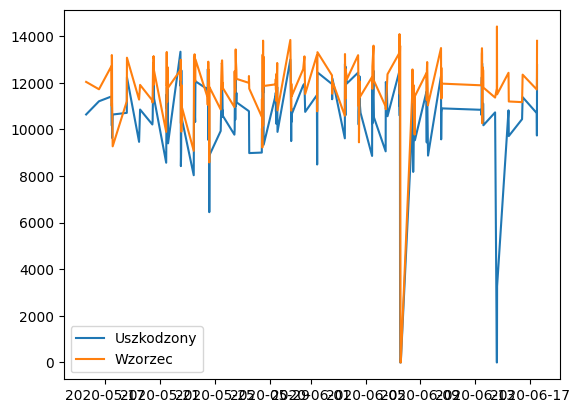
## 3. Kluczowe Wnioski
Na podstawie analizy danych z okresu:
* **Wykryto anomalie:** Dwa inwertery (`1BY6WEcLGh8j5v7`, `bvBOhCH3iADSZry`) wykazują istotnie niższą produkcję energii.
* **Skala problemu:** Całkowita produkcja dla uszkodzonych jednostek jest o **~11.2% niższa** w porównaniu do mediany farmy.
* **Rekomendacja:** Zalecana natychmiastowa inspekcja techniczna wskazanych urządzeń.


In [ ]:
import kagglehub
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import os

# Download latest version
path = kagglehub.dataset_download("anikannal/solar-power-generation-data")


In [ ]:
# Wczytanie danych z pliku
gen_df = pd.read_csv(path + '/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv(path+"/Plant_1_Weather_Sensor_Data.csv")

print("Pierwsze 5 wierszy tabeli generacji:")
display(gen_df.head())

print("\nInformacje o kolumnach:")
gen_df.info()

In [ ]:
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

gen_df.info()
weather_df.info()


In [ ]:
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='left')
df.head()

In [ ]:
df[(df['IRRADIATION'] > 0.1) & (df['DC_POWER'] == 0)].head()

In [ ]:
df = df[df['IRRADIATION'] > 0]

In [ ]:
df['EFFICIENCY'] = df['AC_POWER']/df['IRRADIATION']
df['EFFICIENCY'].describe()

In [ ]:
plt.figure(figsize=(10,6))
sbn.scatterplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY', hue='IRRADIATION', palette='viridis', alpha=0.5)
plt.title('Wpływ temperatury na sprawność')
plt.grid(True)
plt.show

In [ ]:
# Pozbycie się szumów spowodowanych niską wydajnością inwerterów (ciemny kolor po lewej stronie wykresu)
df = df[df['IRRADIATION'] > 0.8]
plt.figure(figsize=(10,6))
sbn.scatterplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY', hue='IRRADIATION', palette='viridis', alpha=0.5)
plt.title('Wpływ temperatury na sprawność')
plt.grid(True)
plt.show


In [ ]:
columns = ['EFFICIENCY', 'MODULE_TEMPERATURE', 'IRRADIATION']
print(df[columns].corr())

In [ ]:
sbn.regplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY')

In [ ]:
df = df.rename(columns={'SOURCE_KEY_x': 'INVERTER_ID'})
plt.figure(figsize=(15, 8))
sbn.boxplot(data=df, x='INVERTER_ID',y='DC_POWER')
plt.xticks(rotation=90)
plt.show()

In [32]:
total_yield = df.groupby('INVERTER_ID')['DC_POWER'].sum()

In [ ]:
total_yield.median()

In [33]:
df.groupby('INVERTER_ID')['DC_POWER'].sum().sort_values()

,DC_POWER
INVERTER_ID,
bvBOhCH3iADSZry,2.263525e+06
1BY6WEcLGh8j5v7,2.298095e+06
z9Y9gH1T5YWrNuG,2.485455e+06
ih0vzX44oOqAx2f,2.501028e+06
sjndEbLyjtCKgGv,2.512870e+06
WRmjgnKYAwPKWDb,2.522345e+06
pkci93gMrogZuBj,2.529469e+06
wCURE6d3bPkepu2,2.531695e+06
rGa61gmuvPhdLxV,2.540213e+06


In [ ]:
x = (2550199.0387204997 - 2.263525e+06) / 2550199.0387204997
print(x)

In [40]:
faulty_inv = df[df['INVERTER_ID'] == '1BY6WEcLGh8j5v7']
healthy_inv = df[df['INVERTER_ID'] == 'McdE0feGgRqW7Ca']

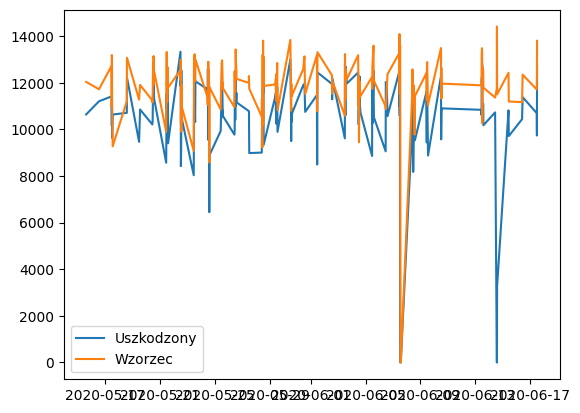

In [41]:
plt.plot('DATE_TIME', 'DC_POWER', data=faulty_inv, label='Uszkodzony')
plt.plot('DATE_TIME', 'DC_POWER', data=healthy_inv, label='Wzorzec')
plt.legend()